![head.png](https://github.com/iwh-halle/FinancialDataAnalytics/blob/master/figures/head.jpg?raw=1)

# Financial Data Analytics in Python

**Prof. Dr. Fabian Woebbeking**</br>
Assistant Professor of Financial Economics

IWH - Leibniz Institute for Economic Research</br>
MLU - Martin Luther University Halle-Wittenberg

fabian.woebbeking@iwh-halle.de

## Please follow these rules:

1. Do NOT change the name of this file.
2. The numerical result (if applicable) of each task must be printed, e.g.
    ```python
    result = 1/3
    print(result)
    ```
3. Do not format any printed output using `print(f"...")`. Print **numeric or variable results** directly (see example above).
4. Do **not** round results at any point in your calculations.
5. Do not **change or remove the last code cell**. It is necessary for conversion and grading.


From this point onward, you may start adding your solutions, you can add as many code and markdown cells as you like. However, please follow the print instructions exactly to ensure your submission is autograded correctly.

# Part 1: Basics
### Task:

In [33]:
def present_value(C_t, r, t):
    """ Function to calculate present value 

     Parameters:
        C_t (float): Future cash flow
        r (float): Interest rate (as decimal)
        t (int): Time period

    Returns:
        float: Present value

    """
    return C_t / (1 + r)**t

pv = present_value(100, 0.03, 10)
print("The present value is:", pv)

The present value is: 74.4093914896725


### Task:

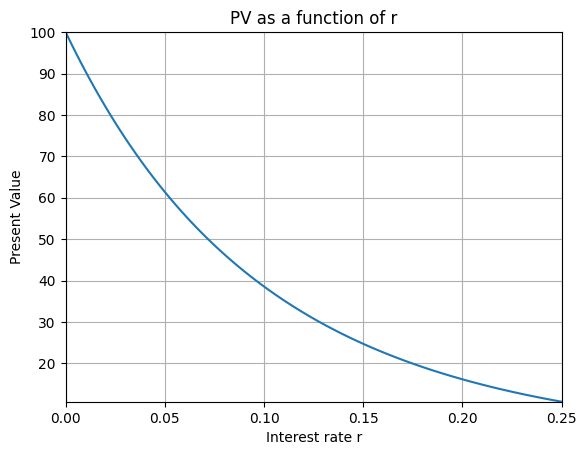

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
C_t = 100
t = 10

# r for 0-25 %
r_values = np.linspace(0, 0.25, 100)

# collecting present values for every r 
pv_values = present_value(C_t, r_values, t)

# Plot
plt.plot(r_values, pv_values)
plt.xlabel("Interest rate r")
plt.ylabel("Present Value")
plt.title("PV as a function of r")
plt.grid()
plt.margins(0)
plt.show()

### Task:

In [36]:
cashflows = [10, 10, 110]
r = 0.05

print("Discounted Cash Flows:")

total_pv = 0

for t, C_t in enumerate(cashflows, start=1):
    pv = C_t / (1 + r)**t
    total_pv += pv
    print("Year", t, "CF =", C_t, "PV =", pv)

print("Total Present Value:", total_pv)

Discounted Cash Flows:
Year 1 CF = 10 PV = 9.523809523809524
Year 2 CF = 10 PV = 9.070294784580499
Year 3 CF = 110 PV = 95.02213583846236
Total Present Value: 113.61624014685239


# Part 2: Data
### Task:
### Loading Data and getting returns

In [5]:
import pandas as pd
import os
import numpy as np

os.chdir("C:/Users/Jonas/Desktop/Data Analytics/rep/02-python-jonahein")

# load data
prices = pd.read_csv(
    "02_python_data.csv",
    parse_dates=["Date"],
    index_col="Date"
)
prices = prices.sort_index()

# returns
returns = prices.pct_change()

# log returns
logreturns = np.log(1 + returns)

# results
print("Returns:")
print(returns.head())

print("Log Returns:")
print(logreturns.head())



Returns:
              .GDAXI   SAPG.DE  SIEGn.DE  DTEGn.DE   AIRG.DE   ALVG.DE  \
Date                                                                     
2022-04-29       NaN       NaN       NaN       NaN       NaN       NaN   
2022-05-02 -0.011265 -0.010763 -0.022584 -0.015936 -0.014597 -0.005550   
2022-05-03  0.007203 -0.013056 -0.004864  0.004974  0.023855  0.009302   
2022-05-04 -0.004890 -0.018478  0.010649  0.008863 -0.035325 -0.015899   
2022-05-05 -0.004889  0.018505  0.006910  0.003537  0.061161 -0.064575   

             MBGn.DE  VOWG_p.DE   BMWG.DE   SHLG.DE  ...   CONG.DE   HEIG.DE  \
Date                                                 ...                       
2022-04-29       NaN        NaN       NaN       NaN  ...       NaN       NaN   
2022-05-02 -0.072727  -0.011548 -0.011081 -0.020289  ... -0.053923 -0.009410   
2022-05-03  0.010608   0.020242  0.030139  0.003982  ...  0.029779  0.008769   
2022-05-04 -0.008747  -0.011185 -0.006377  0.030940  ... -0.015858  0.00

### Task
### Histogram DAX

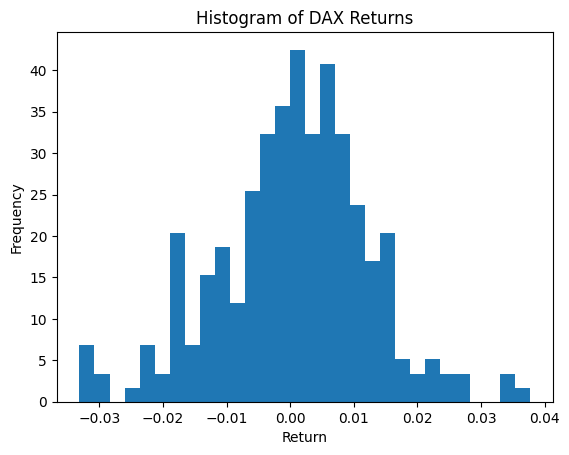

In [6]:
import matplotlib.pyplot as plt

#plot
plt.hist(returns.iloc[:, 0], bins=30, density=True)

plt.title("Histogram of DAX Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.show()

### Retuns and Prices

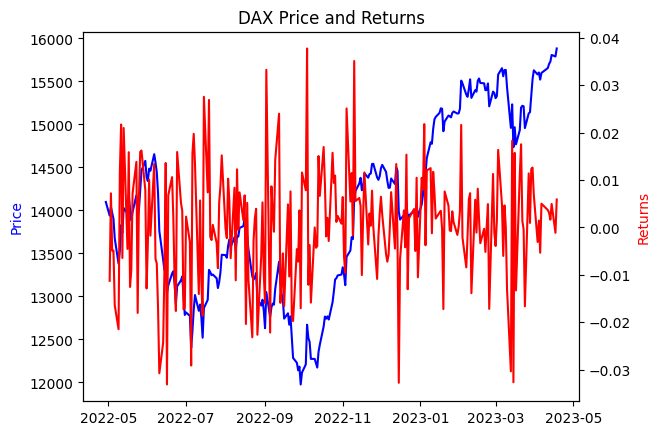

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# prices
ax1.plot(prices.iloc[:, 0], color="blue")
ax1.set_ylabel("Price", color="blue")

# Returns 
ax2 = ax1.twinx()
ax2.plot(returns.iloc[:, 0], color="red")
ax2.set_ylabel("Returns", color="red")

plt.title("DAX Price and Returns")
plt.show()

### Task:
### Highest average returns

In [11]:
# average returns per company
avg_returns = returns.mean()

# company with highest average return
best_company = avg_returns.idxmax()

# print results
print("Company with highest average return:")
print(best_company)

print("Average return:")
print(avg_returns.max())

Company with highest average return:
CBKG.DE
Average return:
0.002436833660191267


### Task:
### Heatmap

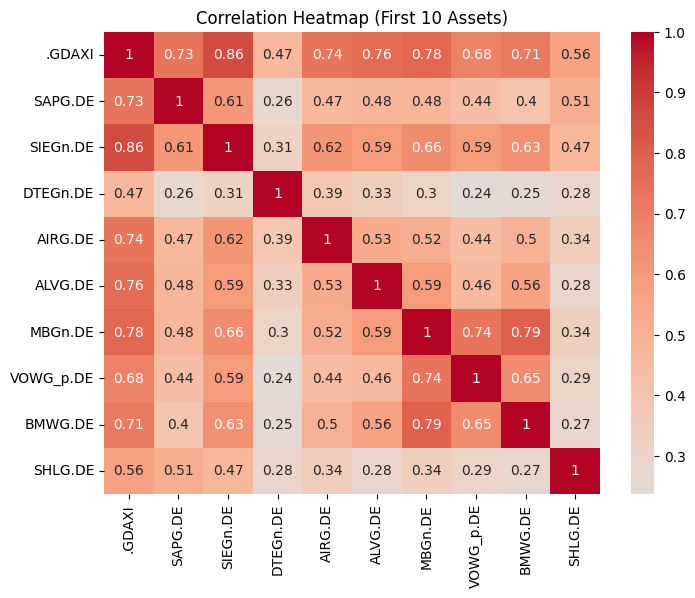

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# first 10 assets
returns_10 = returns.iloc[:, :10]

# correlation
corr_matrix = returns_10.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0.2)

plt.title("Correlation Heatmap (First 10 Assets)")
plt.show()

# The End

<div style="color: red; font-weight: bold; font-size: 18px">
⚠️ DO NOT MODIFY OR MOVE THE CODE CELL BELOW! ⚠️
</div>

The following code **must remain unchanged** and at the end of the script and **must be executed once your homework is completed**.

This block converts your notebook to a `.py` file for GitHub Classroom autograding. After you have completed the assignment, simply run the entire notebook again and you should see a file called solutions.py, which we will use for autograding. You can run - and therefore recreate solutions.py - as often as you want.

In [ ]:
# Convert notebook to script
try:
    # Check if running in a Jupyter notebook
    shell = get_ipython().__class__.__name__
    if shell == 'ZMQInteractiveShell':
        import os
        os.system('jupyter nbconvert solutions.ipynb --to script')
except NameError:
    pass